**Phần 1:**

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

print(df.describe())
print(f"\nVar:\n{df.var(numeric_only= True)}")
print(f"\nMode:\n{df.mode(numeric_only = True).iloc[0]}")
q1 = df.quantile(0.25, numeric_only= True)
q3 = df.quantile(0.75, numeric_only = True)
iqr = q3-q1
print(f"\nIQR:\n{iqr}")
group_species = df.groupby('species').agg(['mean','std']).T
print(f"\n{group_species}")

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.

Mean của loài setosa chênh lệch rất lớn so với 2 loài còn lại, đặc biệt ở 2 biến số petal_length và petal_width nhỏ hơn rất nhiều so sánh với 2 loài kia.

Mean của versicolor và virginica khá tương đồng ở các biến số.

Ngoài ra, xét về độ phân tán dữ liệu thì loài virginica có giá trị std cao nhất ở 3 biến sepal_length, petal_length và petal_width, có nghĩa là các giá trị đó giữa các cá thể sẽ chênh lệch lớn, ít đồng nhất hơn so với 2 loài kia.

**Phần 2:**

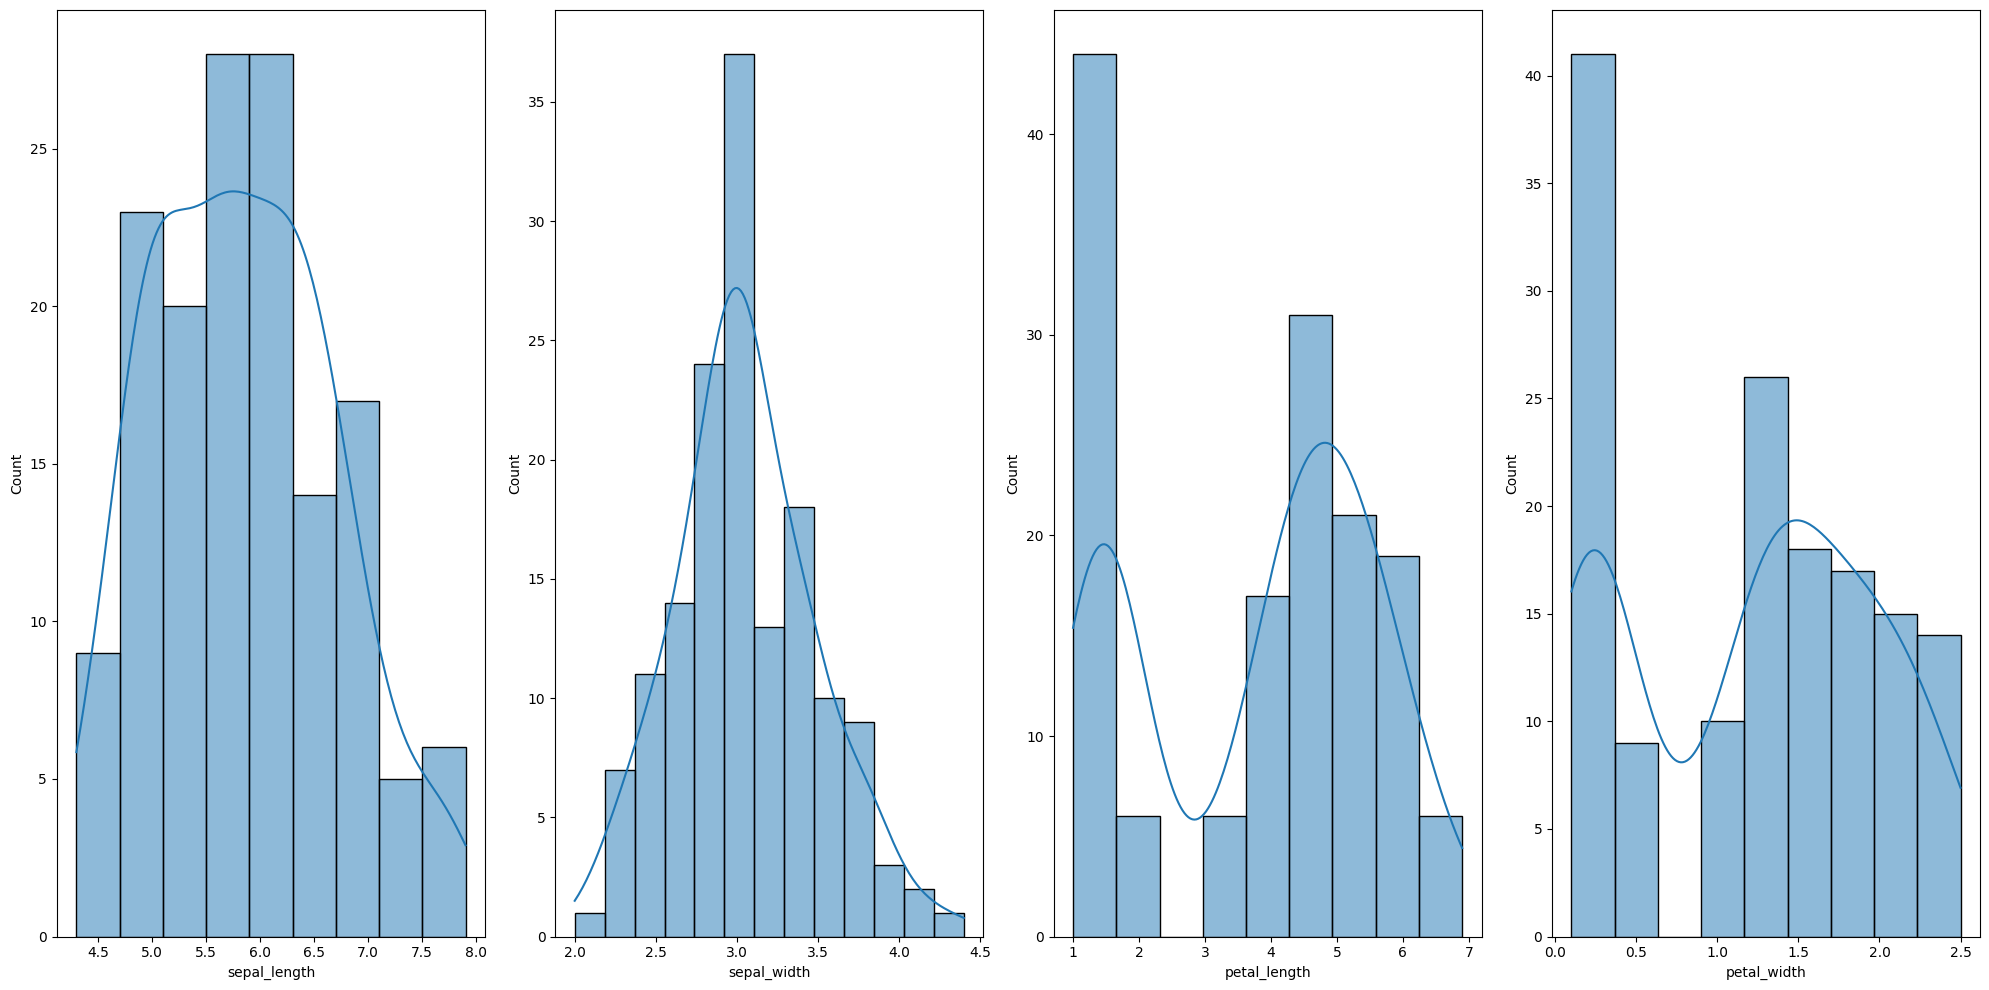

In [3]:
fig, axes = plt.subplots(1,4,figsize=(20,10))
cols = ['sepal_length','sepal_width','petal_length','petal_width']
for i, col in enumerate(cols):
  sns.histplot(data=df, x=col, kde=True, ax=axes[i])
plt.tight_layout()
plt.show()

Sepal_length: Phân phối lệch phải

Sepal_width: Phân phối chuẩn

Petal_length và petal_width: Phân phối đa đỉnh (cụ thể là 2 đỉnh)

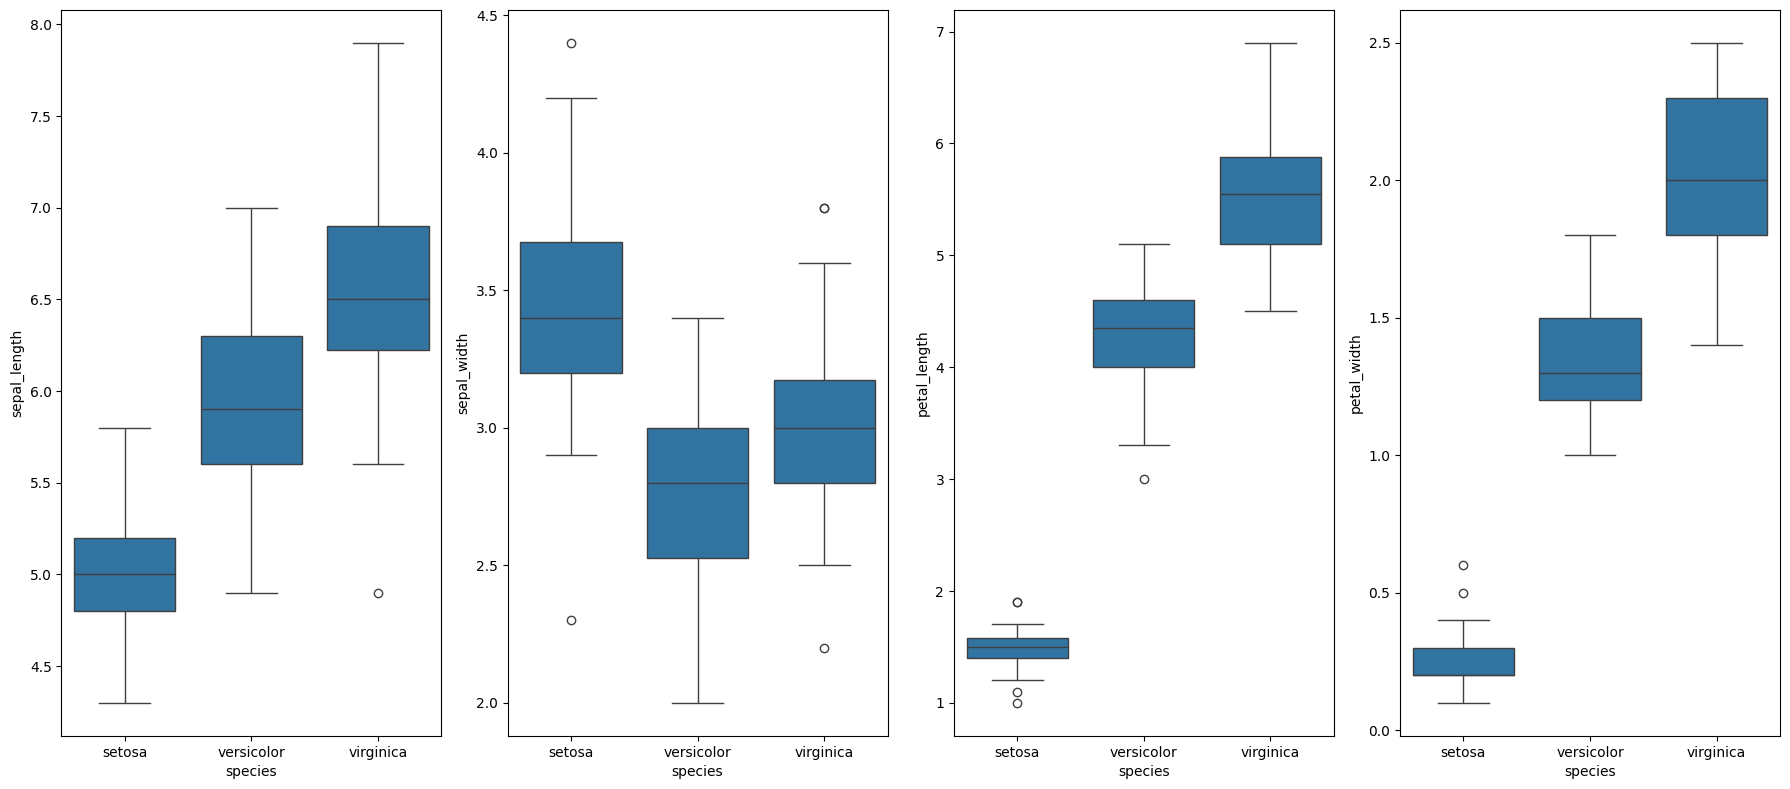

In [4]:
fig, axes = plt.subplots(1,4,figsize=(18,8))
cols = ['sepal_length','sepal_width','petal_length','petal_width']
for i, col in enumerate(cols):
  sns.boxplot(data=df, x='species',y=col, ax=axes[i])
plt.tight_layout()
plt.show()

Sự phân phối của 4 biến số trên 3 loài có khác biệt rõ rệt:


*   Biểu đồ cho thấy ở 2 biến số petal_length và petal_width, boxplot của 3 loài nằm tách biệt rõ, không chồng lên nhau nên có thể dựa vào đây để phân biệt các cá thể, trong khi điều ngược lại xảy ra ở 2 biến số sepal khi boxplot các loài có sự chồng lấn lên nhau.
* Độ phân tán dữ liệu cũng được thể hiện rõ (rất thấp ở 2 biến số petal của loài setosa, cao ở 2 biến số sepal của loài versicolor và petal_width của virginica).
* Có sự xuất hiện của một vài outliers ở các biến số của các loài, cho thấy có sự tồn tại của những cá thể rất khác biệt so với mặt bằng chung loài.


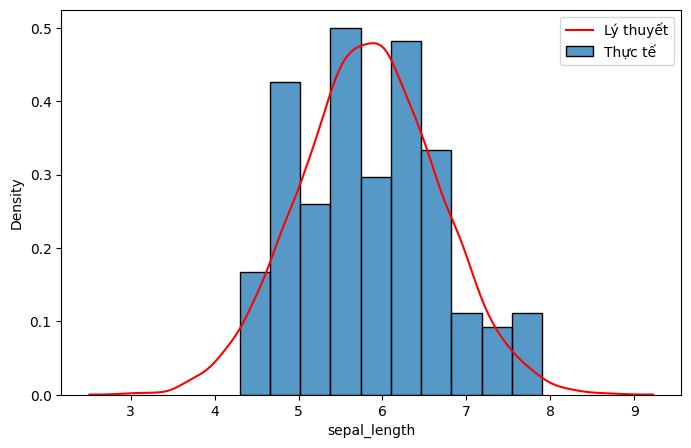

In [18]:
data = df['sepal_length']
mean = data.mean()
std = data.std()
samples = np.random.normal(mean, std, 10000)
plt.figure(figsize=(8,5))
sns.histplot(data, bins = 10, stat = 'density', label ='Thực tế')
sns.kdeplot(samples, color = 'red', label ='Lý thuyết')
plt.legend()
plt.show()

Biểu đồ không tuân theo phân phối chuẩn:
* Tại đỉnh của đường phân phối chuẩn, cột của dữ liệu lại sụt xuống rõ rệt.
* Dự liệu thực tế rất nhấp nhô, không tăng/giảm trơn tru như phân phối chuẩn.

**Phần 3:**

Coviarance:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Correlation:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000



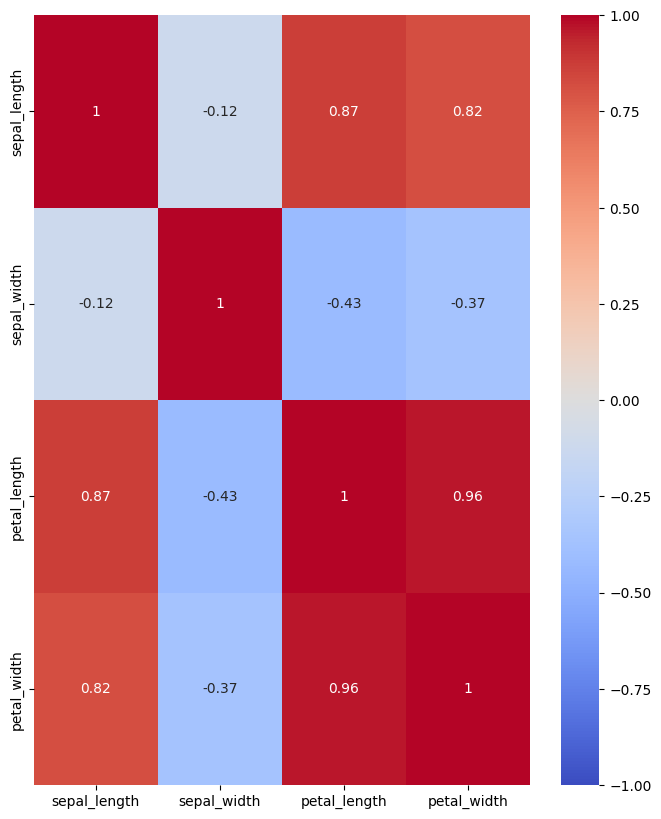

In [27]:
numeric_df = df.select_dtypes(include='number')
cov_matrix = numeric_df.cov()
corr_matrix = numeric_df.corr()
print(f"Coviarance:\n{cov_matrix}")
print(f"\nCorrelation:\n{corr_matrix}\n")

plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin= -1, vmax =1)
plt.show()


Các cặp biến tương quan với nhau mạnh là:
* sepal_length và petal_length: 0.87
* petal_width và sepal_length: 0.82
* petal_width và petal_length: 0.96
=> Có sự xuất hiện của đa cộng tuyến vì độ tương quan của các cặp biến kể trên là rất lớn, đặc biệt là trường hợp petal_width và petal_length đến tận 0.96, điều này gây ra sự dư thừa thông tin, khiến mô hình có thể bị sai lệch.

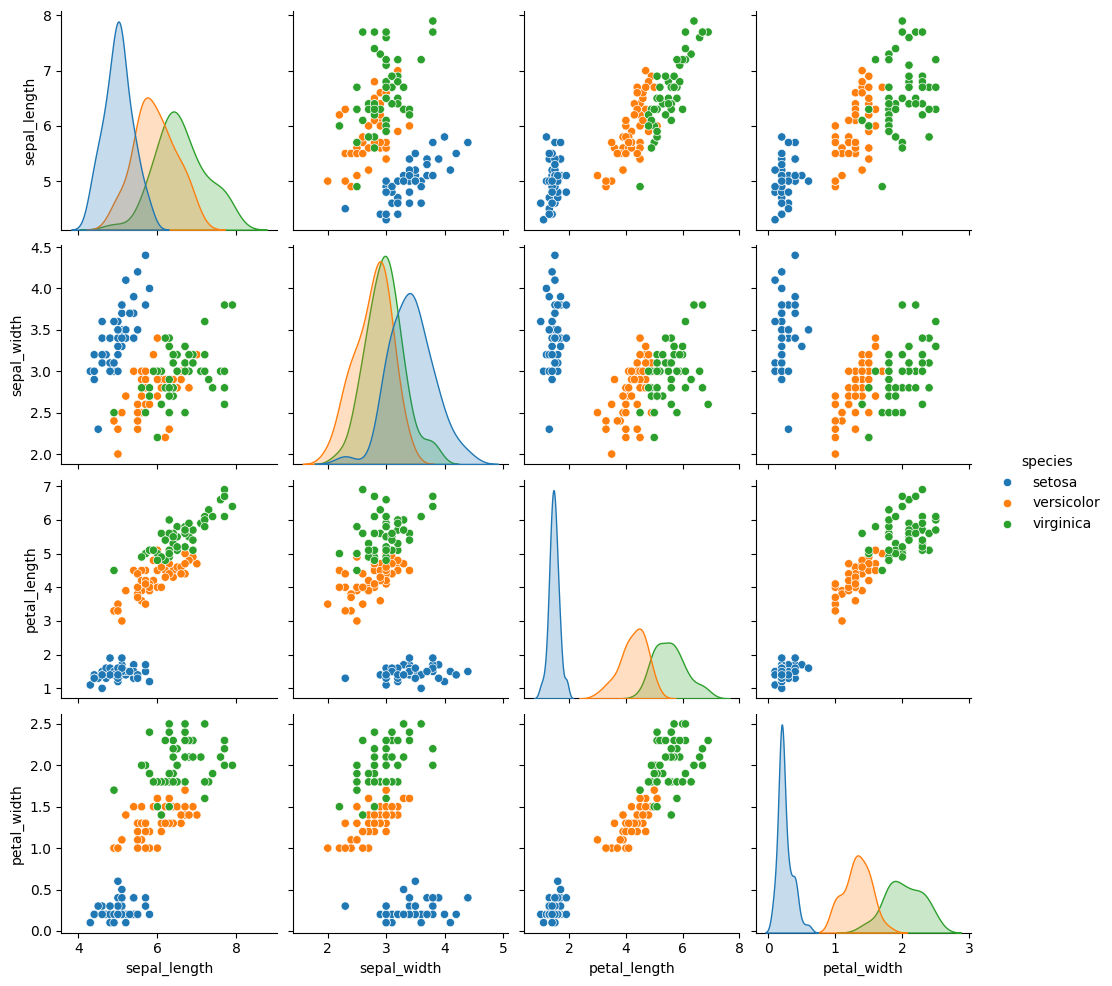

In [33]:
sns.pairplot(df, hue='species')
plt.show()

Ở các ô scatter plot, ta có thể thấy cụm điểm màu xanh dương (Setosa) nằm tách biệt so với 2 loài còn lại (đặc biệt ở 2 hàng petal_width và petal_length). Trong khi đó thì các điểm versicolor và virginica có sự trộn lẫn với nhau khá rõ ràng.

Ở ô scatter plot giao giữa petal_length và petal_width, các điểm có xu hướng xếp thành 1 đường chéo hướng lên, thể hiện mối quan hệ tương quan mạnh (như đã đề cập ở heatmap phía trên).

Ở các ô KDE plot, ta thấy ở 2 hàng petal_width và petal_length thì phân phối của loài setosa nằm riêng biệt ở phần bên trái, và 2 loài còn lại thì có sự giao nhau ở vùng đuôi phân phối, song hai biến này có thể coi như có khả năng phân biệt các loài cao. Trái ngược với 2 hàng còn lại, diện tích giao nhau giữa các phân phối của 3 loài khá đáng kể, thể hiện khả năng phân loại không quá cao của các biến.

**Phần 4:**

P(B|+): 0.1667



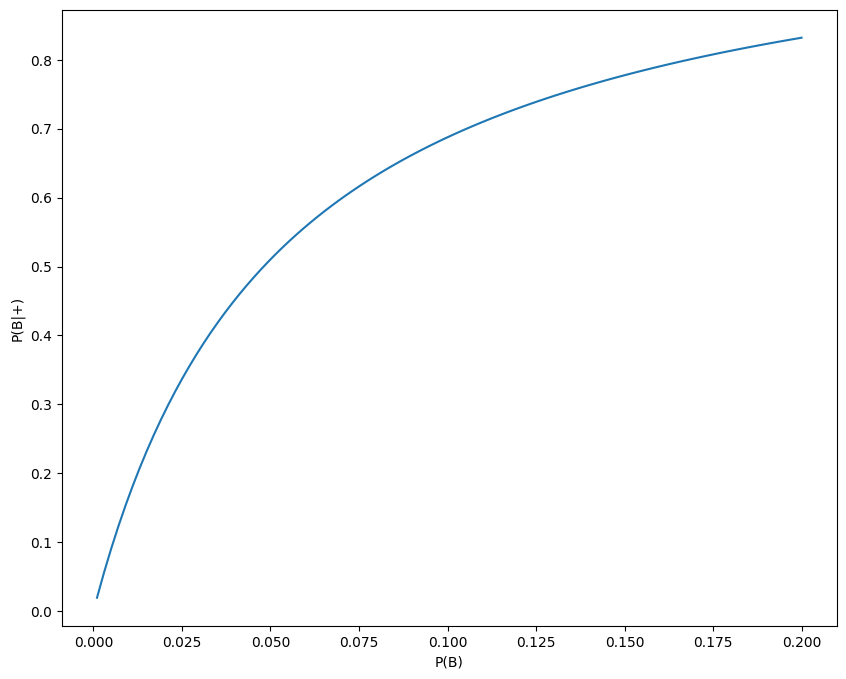

In [47]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05
P_B_given_pos = (P_B*P_pos_givenB)/((P_B*P_pos_givenB)+((1-P_B)*P_pos_givenNB))
print(f"P(B|+): {round(P_B_given_pos, 4)}\n")

P_B_array = np.linspace(0.001, 0.2, 100)
P_B_given_pos_array =  (P_B_array*P_pos_givenB)/((P_B_array*P_pos_givenB)+((1-P_B_array)*P_pos_givenNB))

plt.figure(figsize=(10,8))
plt.plot(P_B_array, P_B_given_pos_array)
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.show()

Vì ta biết độ nhạy của xét nghiệm là rất cao: 99%, vậy khi có kết quả xét nghiệm là dương tính, trực giác sẽ đánh đồng việc đó với gần như là chắc chắn sẽ mắc bệnh (vì độ chính xác gần như là tuyệt đối). Do đó, kết quả của P(B|+) = 16.67% ở trên sẽ khiến chúng ta cảm thấy ngờ ngợ, "phản trực giác". Nhưng sự thật là tỉ lệ mắc bệnh P(B) của dân số là rất thấp: 1%, những người còn lại không mắc bệnh thì lại có 5% xét nghiệm ra dương tính giả, vậy nên khi xét toàn bộ mẫu là những người có xét nghiệm dương tính, tỉ lệ người thật sự nhiễm bệnh không lớn như trực giác chúng ta nghĩ.

In [61]:
P_email = 0.7
P_spam = 0.3
words = {
    'buy': {'email':0.3, 'spam':0.85},
    'tonight': {'email':0.8, 'spam': 0.15},
}
def prob(email):
  email_score = P_email
  spam_score = P_spam
  words_in_email = email.lower().split()
  for word in words_in_email:
    if word in words:
      email_score *= words[word]['email']
      spam_score *= words[word]['spam']
  total_score = email_score + spam_score
  email_prob = email_score/total_score
  spam_prob = spam_score/total_score
  return email_prob, spam_prob

email_list = ["Buy this product with 20% off", "Hey, let's buy some food and watch a movie tonight"]
for email in email_list:
  email_prob, spam_prob = prob(email)
  print(f"{email}\nEmail: {round(email_prob*100, 3)}%, Spam: {round(spam_prob*100, 3)}%")

Buy this product with 20% off
Email: 45.161%, Spam: 54.839%
Hey, let's buy some food and watch a movie tonight
Email: 81.455%, Spam: 18.545%


Xác suất để 1 câu là email thường hay spam: P(email/spam) * P(word1|email/spam) * P(word2|email/spam) *...